In [2]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR

# import yaml 

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [3]:
df_merged = pd.read_csv("dataset_forecast.csv")
df_merged["date"] = pd.to_datetime(df_merged["date"], format='ISO8601' )
df_merged = df_merged[df_merged['date']<='2026-01-01'] # I filter only where I have rows without null values

In [4]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        157 non-null    datetime64[us]
 1   workforce                   157 non-null    float64       
 2   inactives                   157 non-null    float64       
 3   employment_rate             157 non-null    float64       
 4   youth_employment_rate       157 non-null    float64       
 5   activity_rate               157 non-null    float64       
 6   unemployment_rate           157 non-null    float64       
 7   industry_production_prices  157 non-null    float64       
 8   services_production_prices  53 non-null     float64       
 9   companies_trust             156 non-null    float64       
 10  gasoline_car_price          157 non-null    float64       
 11  diesel_price                157 non-null    float64       
 12  GPL_p

In [5]:
meadian_comp_trust= df_merged['companies_trust'].median()
meadian_ind_price = df_merged['industry_production_prices'].median()
df_merged['companies_trust'] = df_merged['companies_trust'].fillna(meadian_comp_trust )
df_merged['industry_production_prices'] = df_merged['industry_production_prices'].fillna(meadian_ind_price )

In [6]:
df_merged = df_merged[['date', 
                         'workforce', 'inactives', 'employment_rate',
                        'youth_employment_rate', 'activity_rate', 'unemployment_rate',
                        'industry_production_prices', 'companies_trust', 'gasoline_car_price',
                        'diesel_price', 'GPL_price', 'diesel_heatining_price']]

# 1. Data Exploration

In [7]:
df_merged[[  'workforce', 'inactives']] = df_merged[[ 'workforce', 'inactives']]*1000

df_merged[[  'workforce', 'inactives']] = df_merged[[  'workforce', 'inactives']].astype(int)

In [9]:
df_merged.head(5)


,date,workforce,inactives,employment_rate,youth_employment_rate,activity_rate,unemployment_rate,industry_production_prices,companies_trust,gasoline_car_price,diesel_price,GPL_price,diesel_heatining_price
0,2013-01-01,24545012,14461505,39.96,54.54,62.93,13.32,94.2,77.7,1.74994,1.69438,0.87203,1.43948
1,2013-02-01,24651944,14350054,41.10,54.82,63.21,13.27,94.3,76.5,1.78100,1.69967,0.85676,1.45680
2,2013-03-01,24585629,14412556,40.20,54.94,63.04,12.86,94.3,78.1,1.79691,1.69394,0.84149,1.43179
3,2013-04-01,24489735,14505159,39.02,54.78,62.80,12.78,93.9,74.2,1.75380,1.65111,0.81166,1.40430
4,2013-05-01,24531196,14459758,40.39,55.04,62.92,12.51,93.9,75.9,1.71616,1.61231,0.77374,1.37599


In [10]:
numeric = [    'workforce', 'inactives', 'employment_rate',
            'youth_employment_rate', 'activity_rate', 'unemployment_rate',
            'industry_production_prices', 'companies_trust', 'gasoline_car_price',
            'diesel_price', 'GPL_price', 'diesel_heatining_price',  "date"]

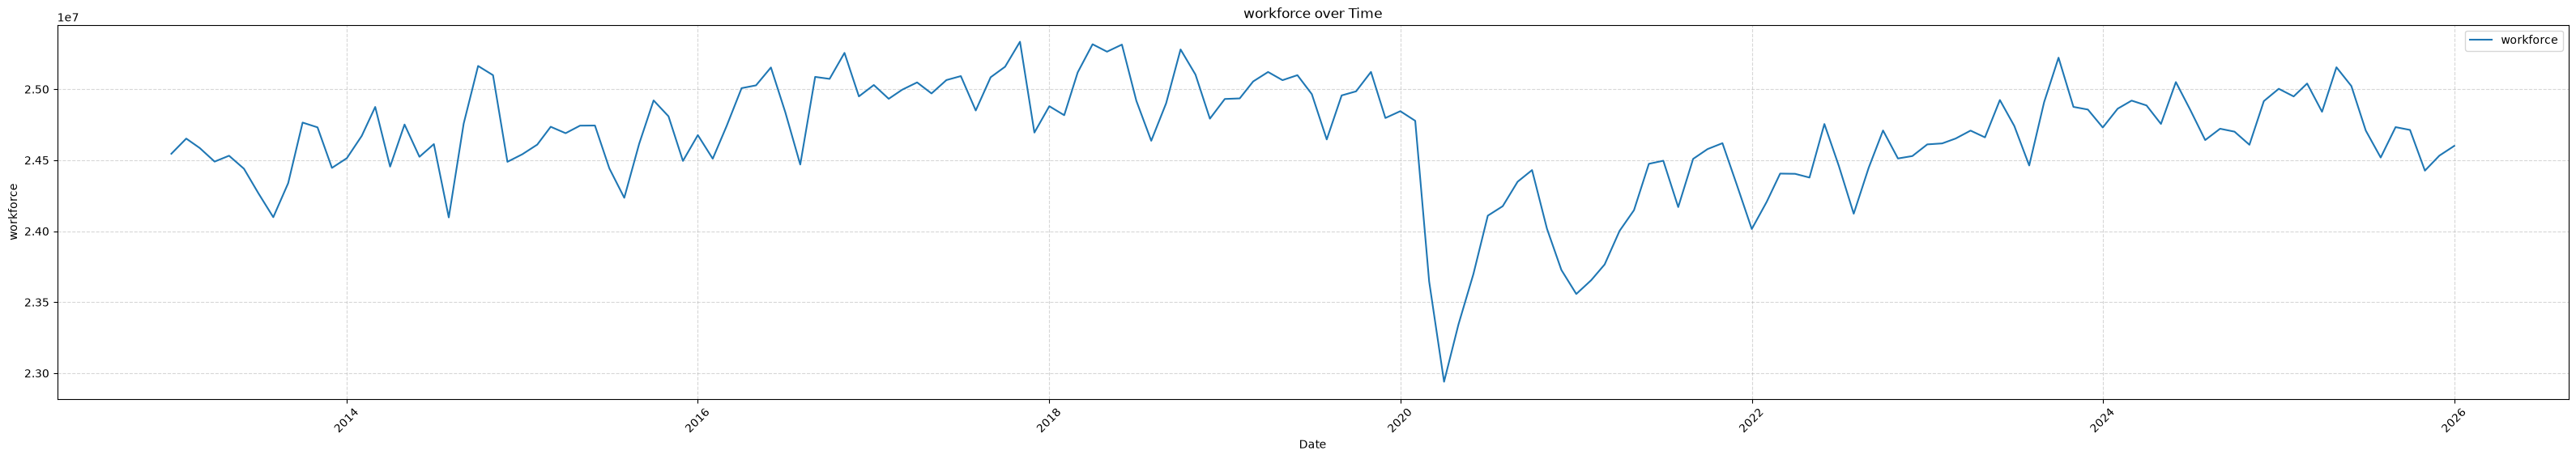

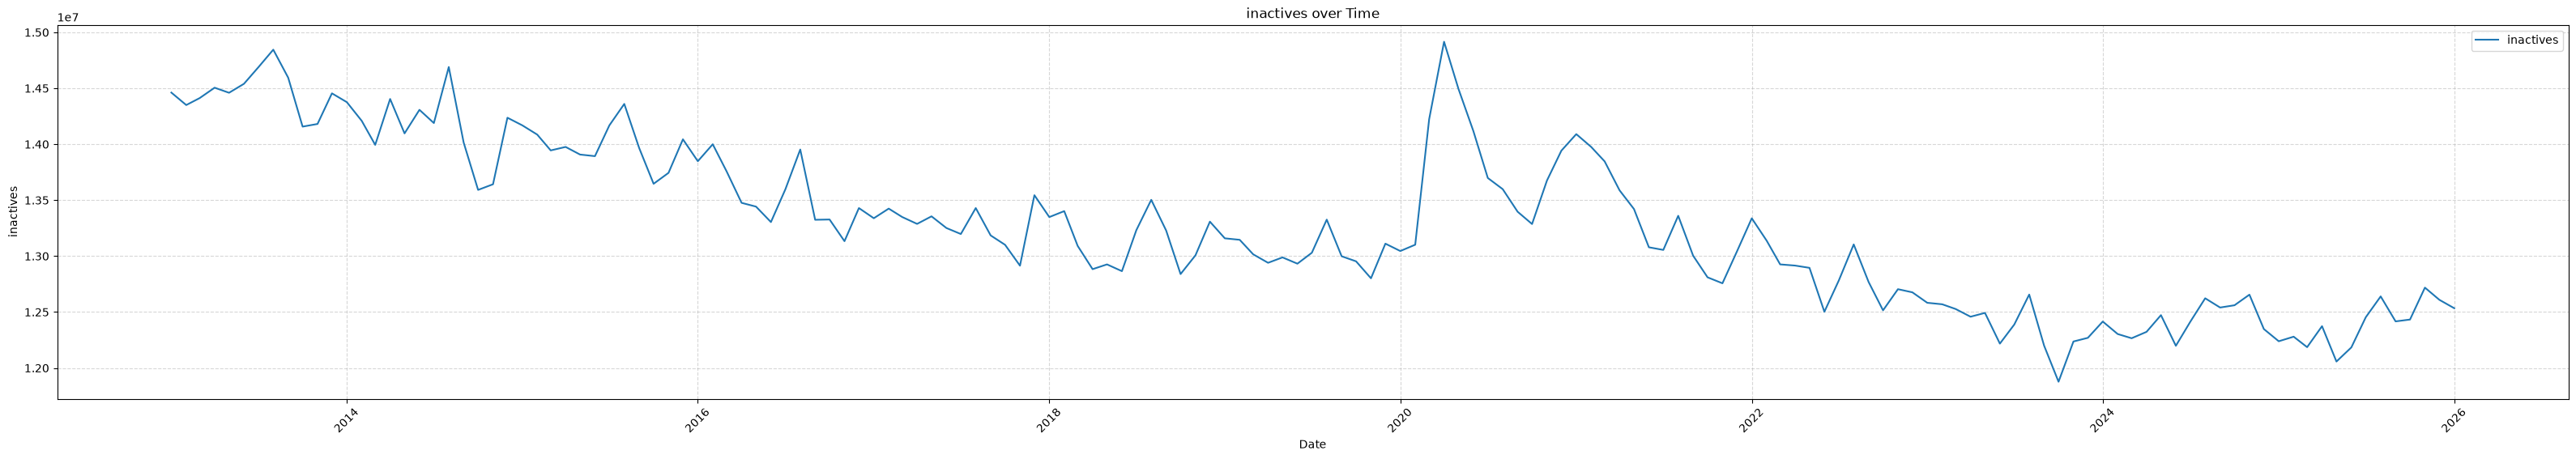

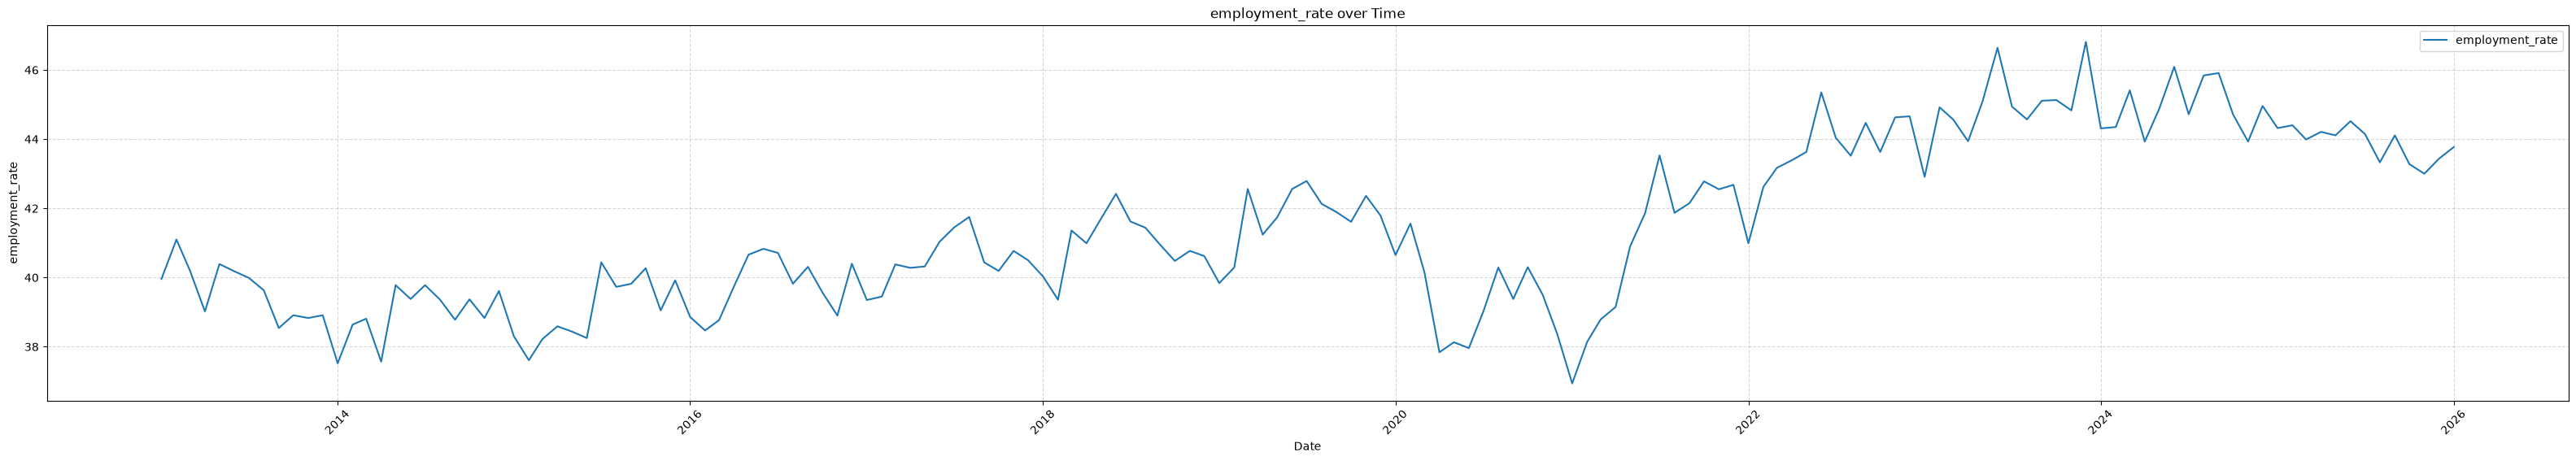

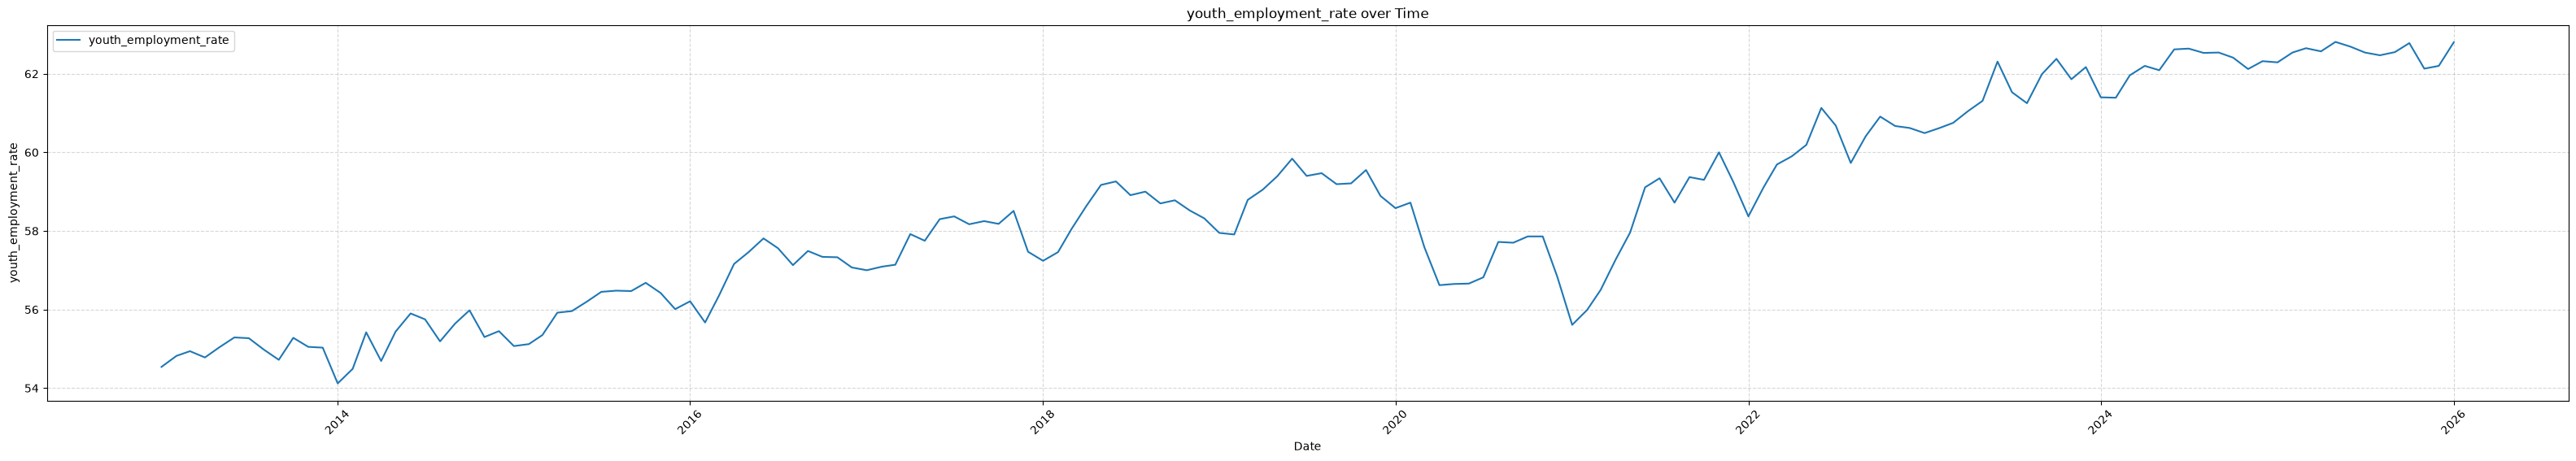

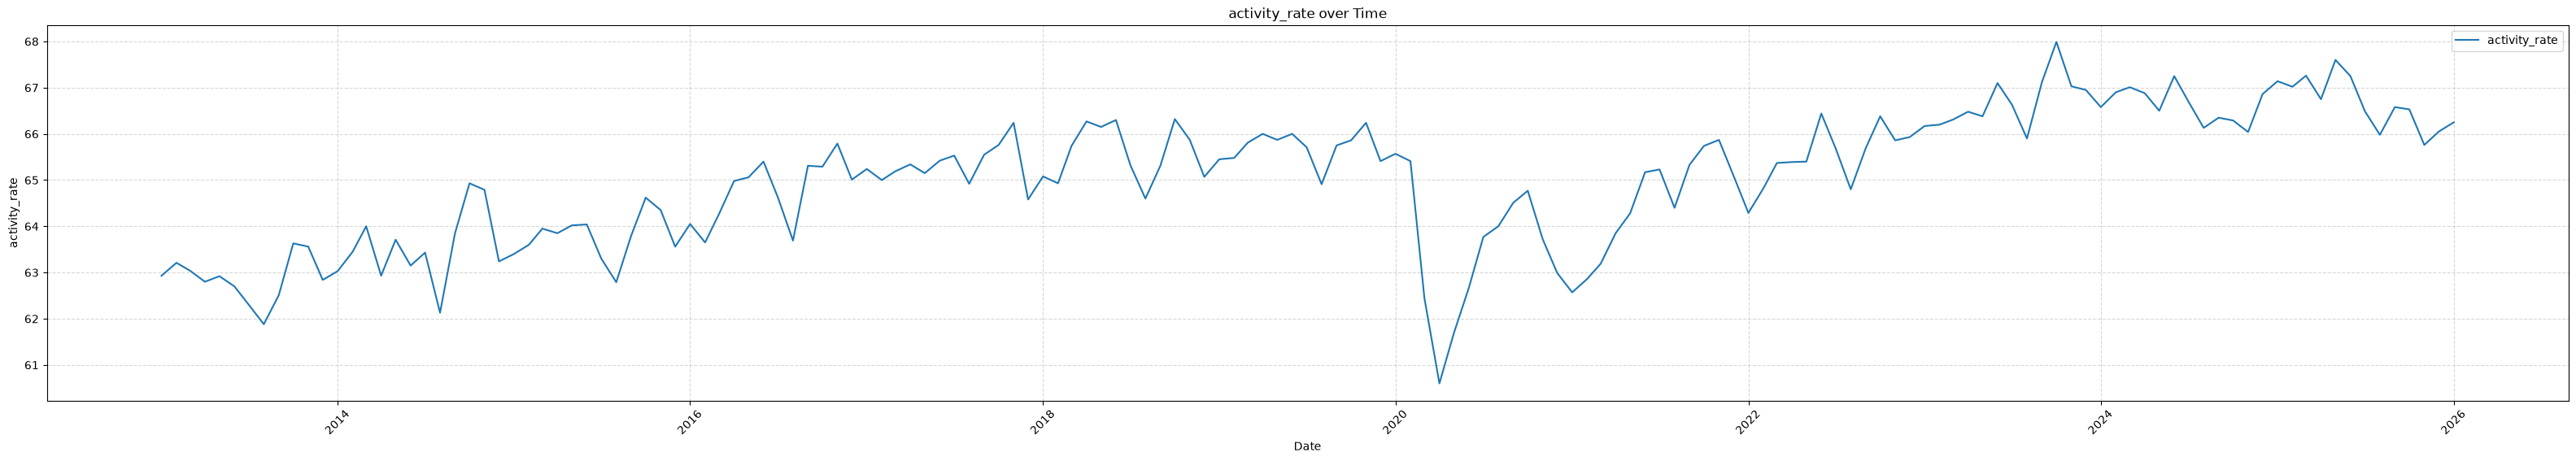

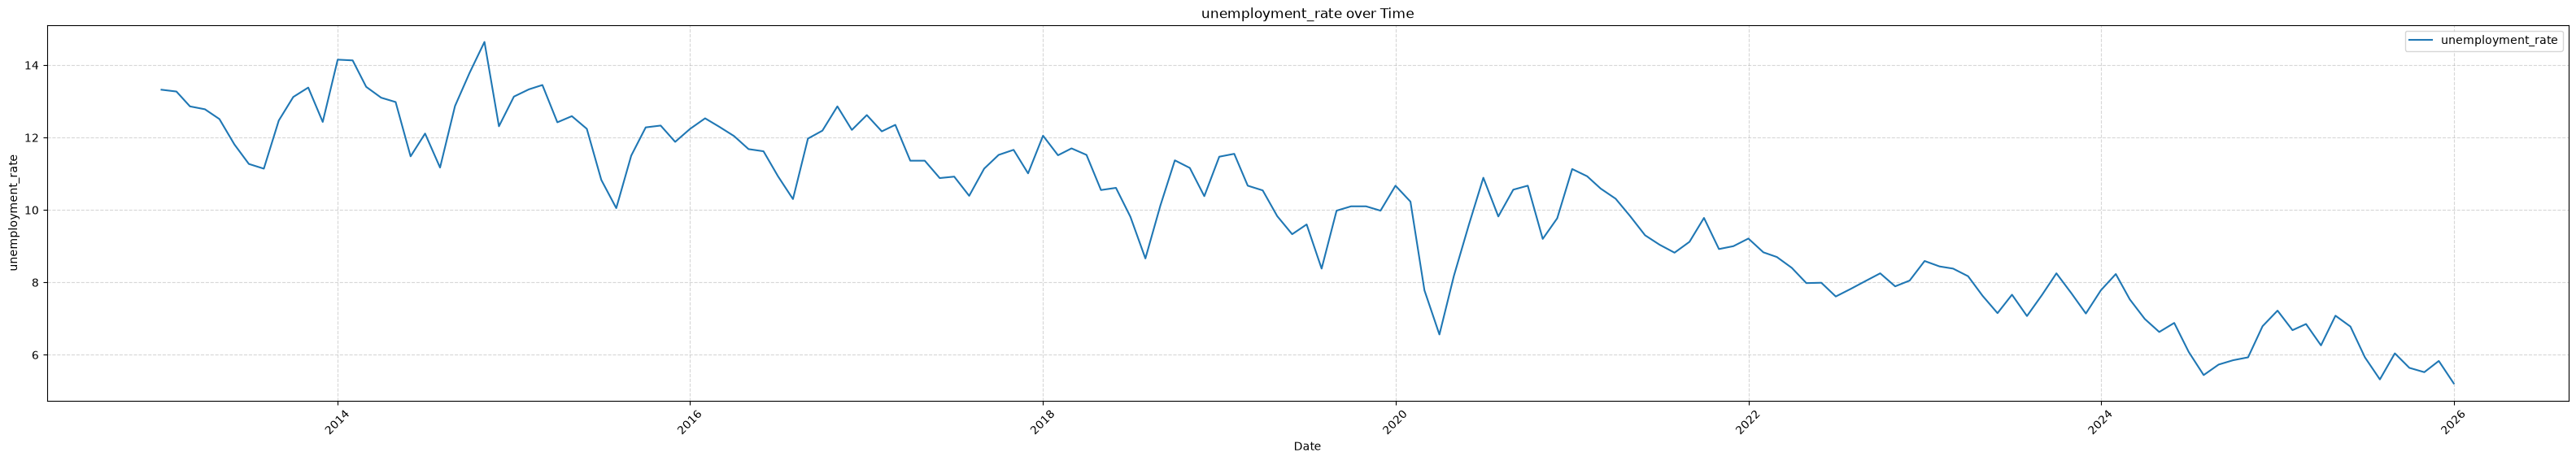

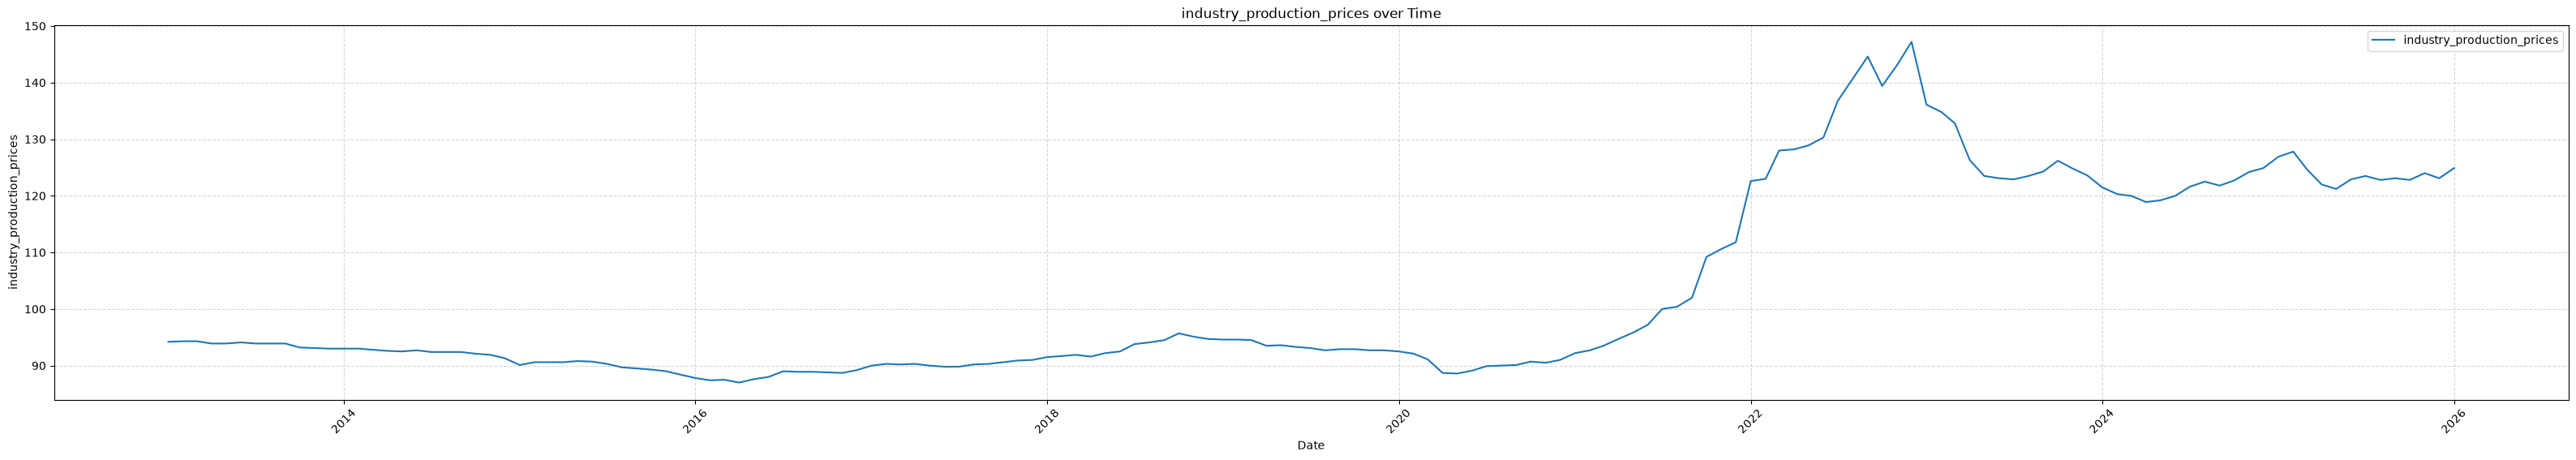

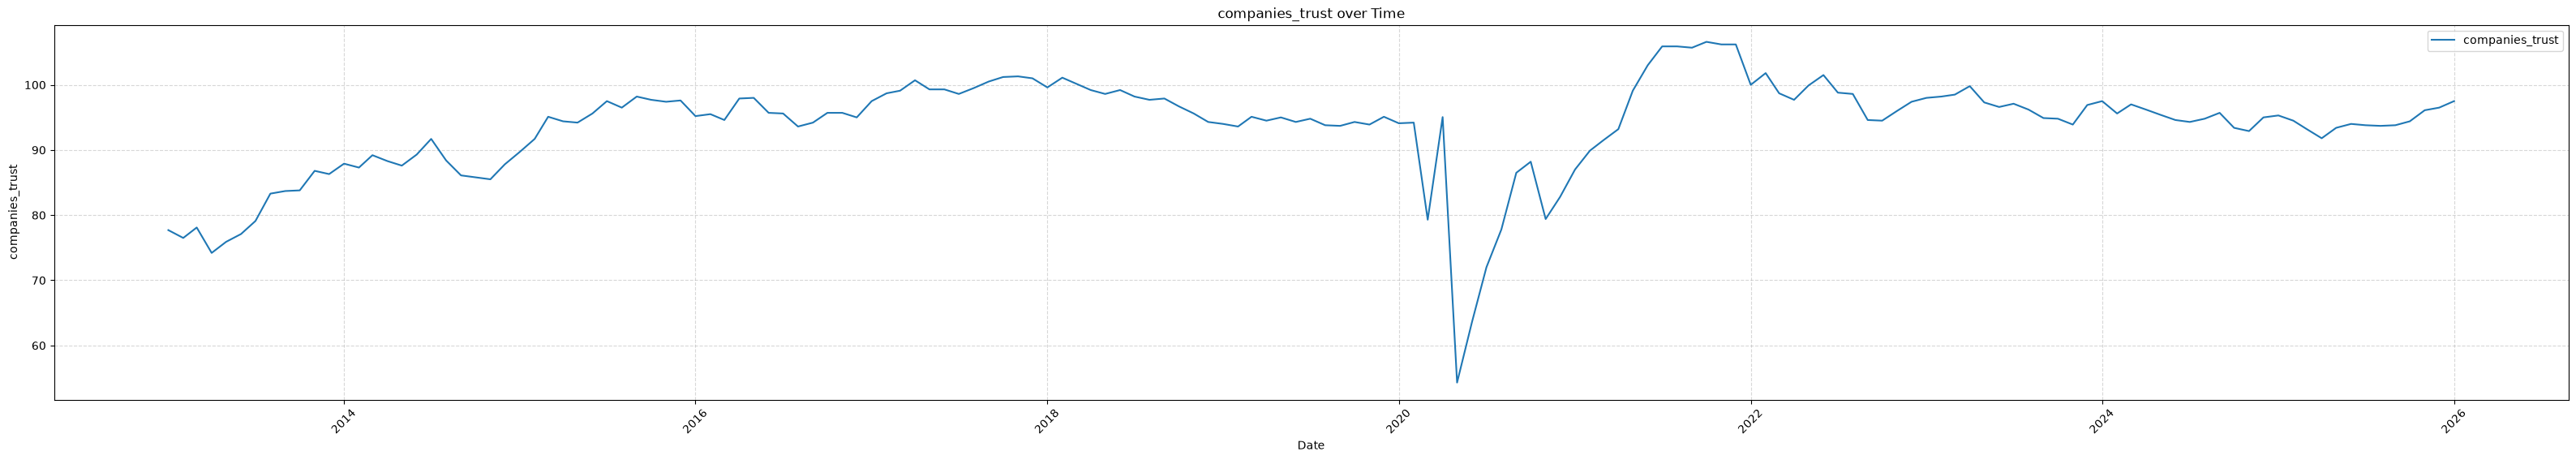

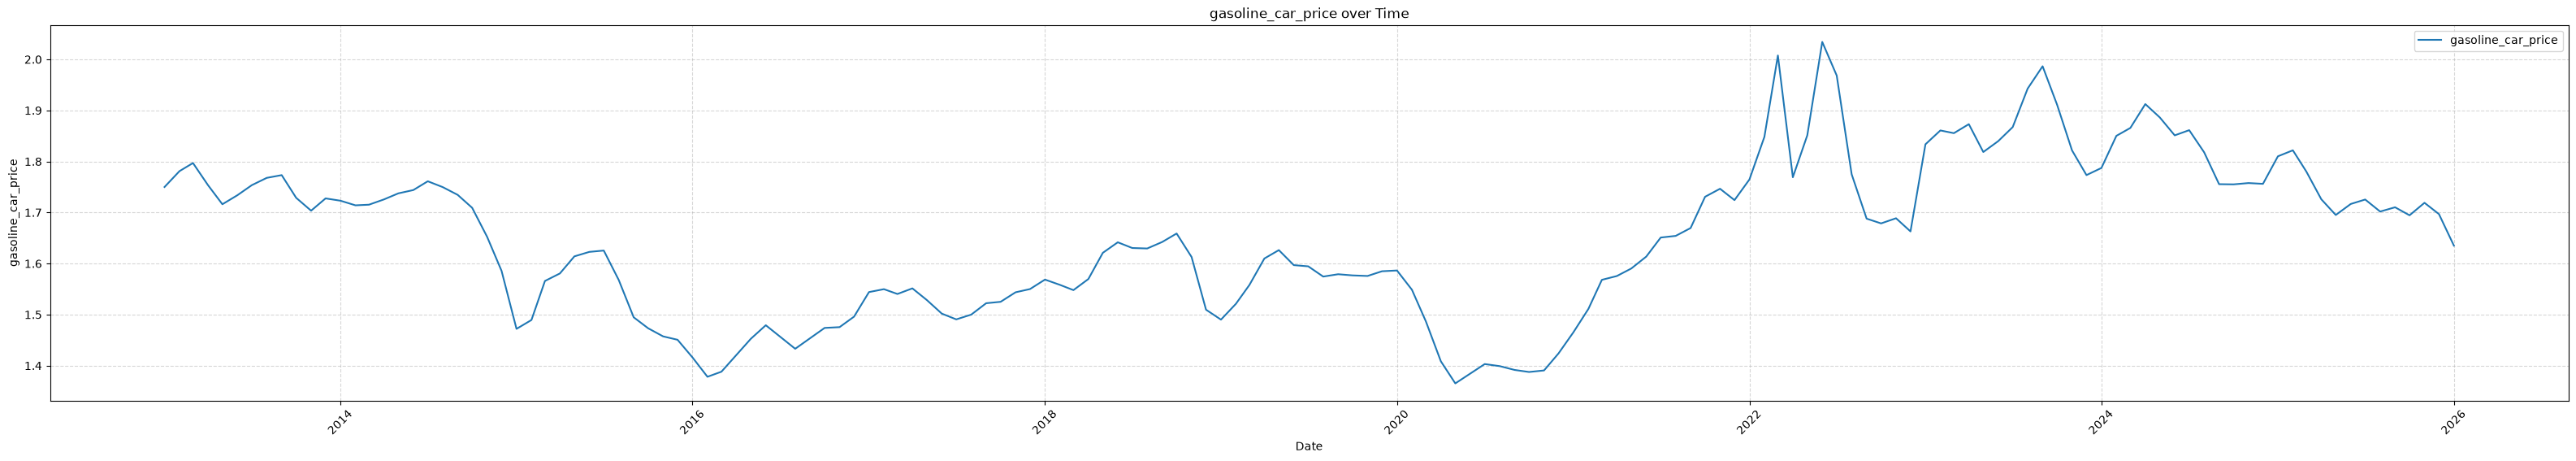

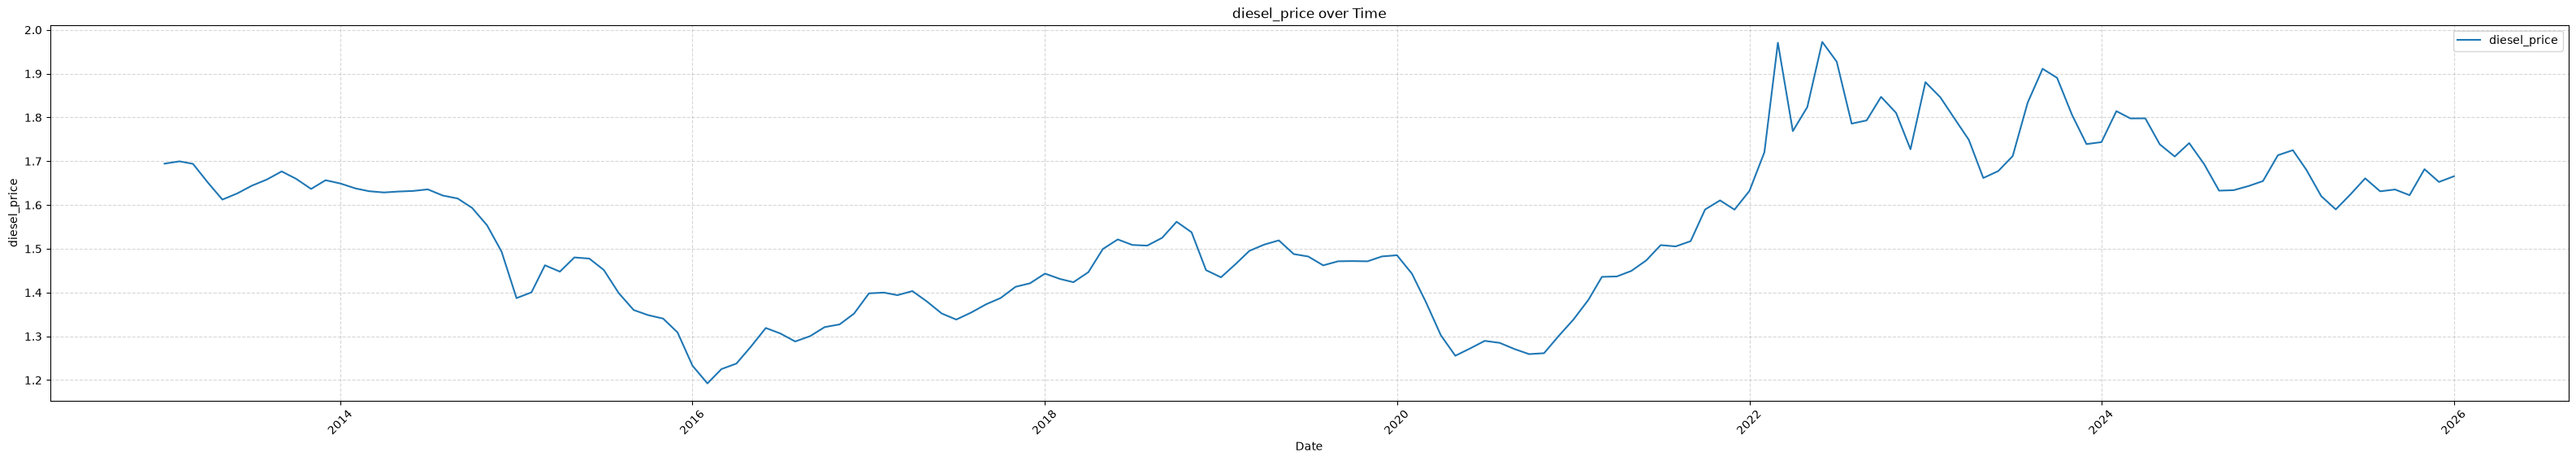

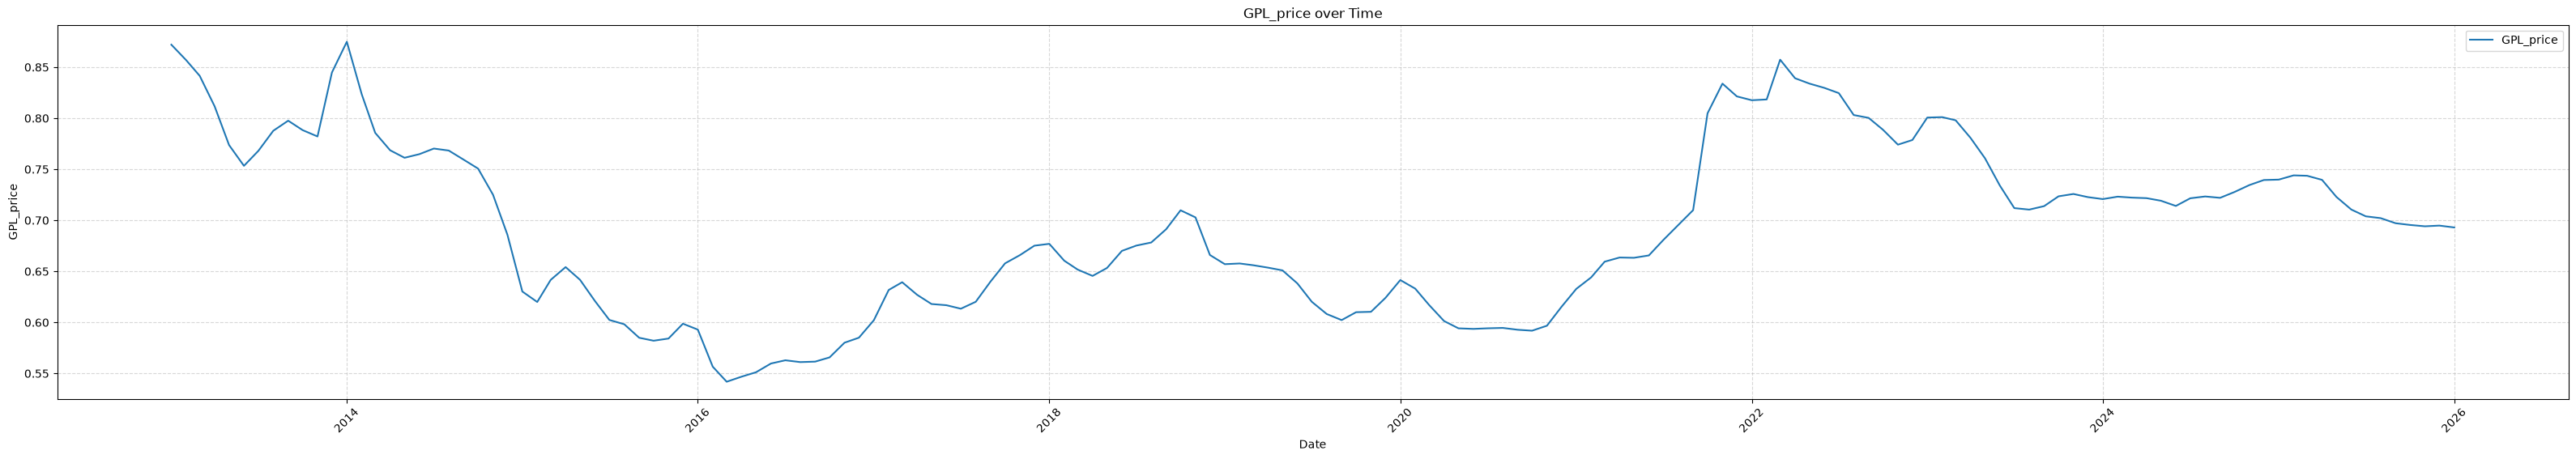

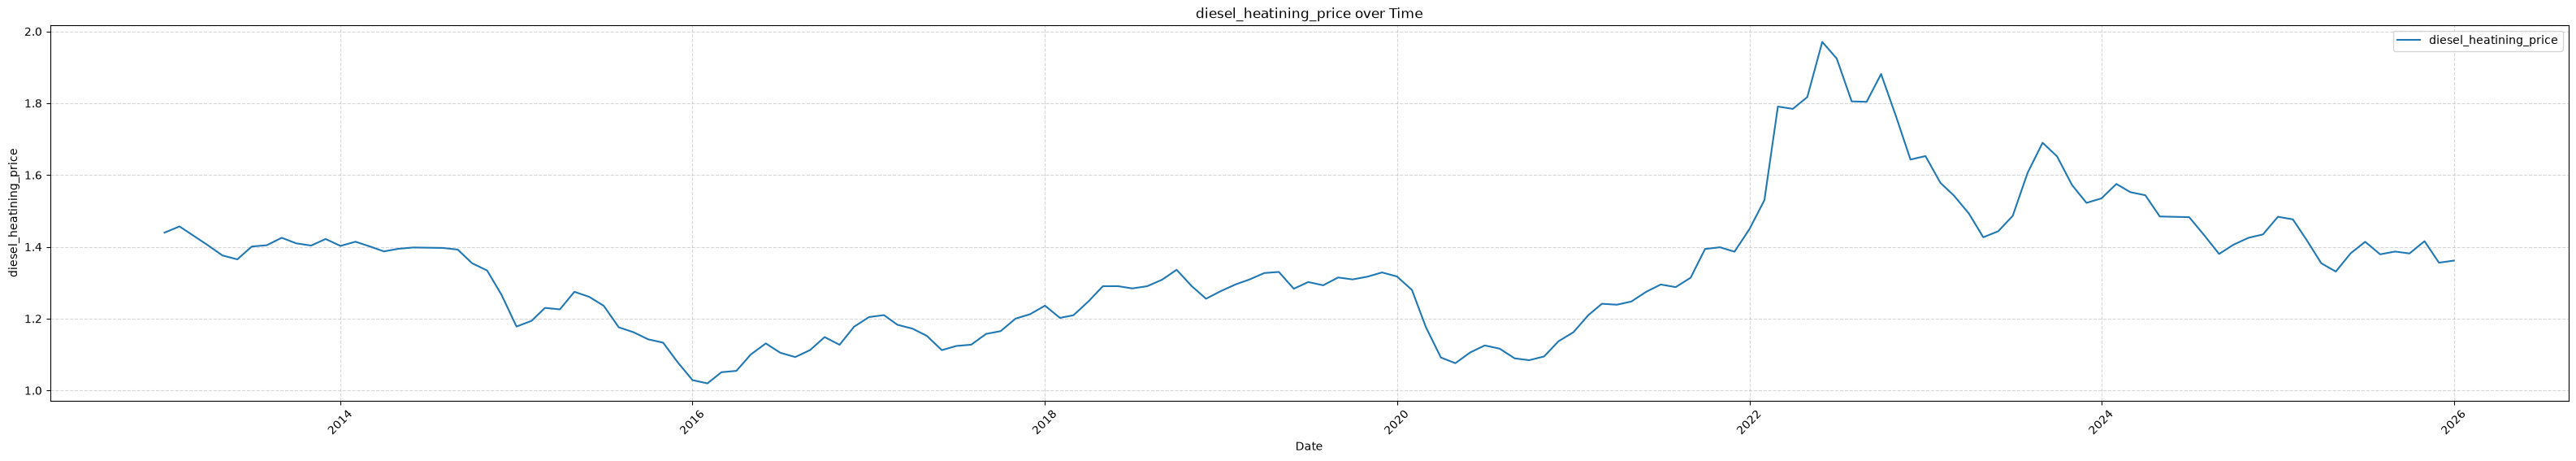

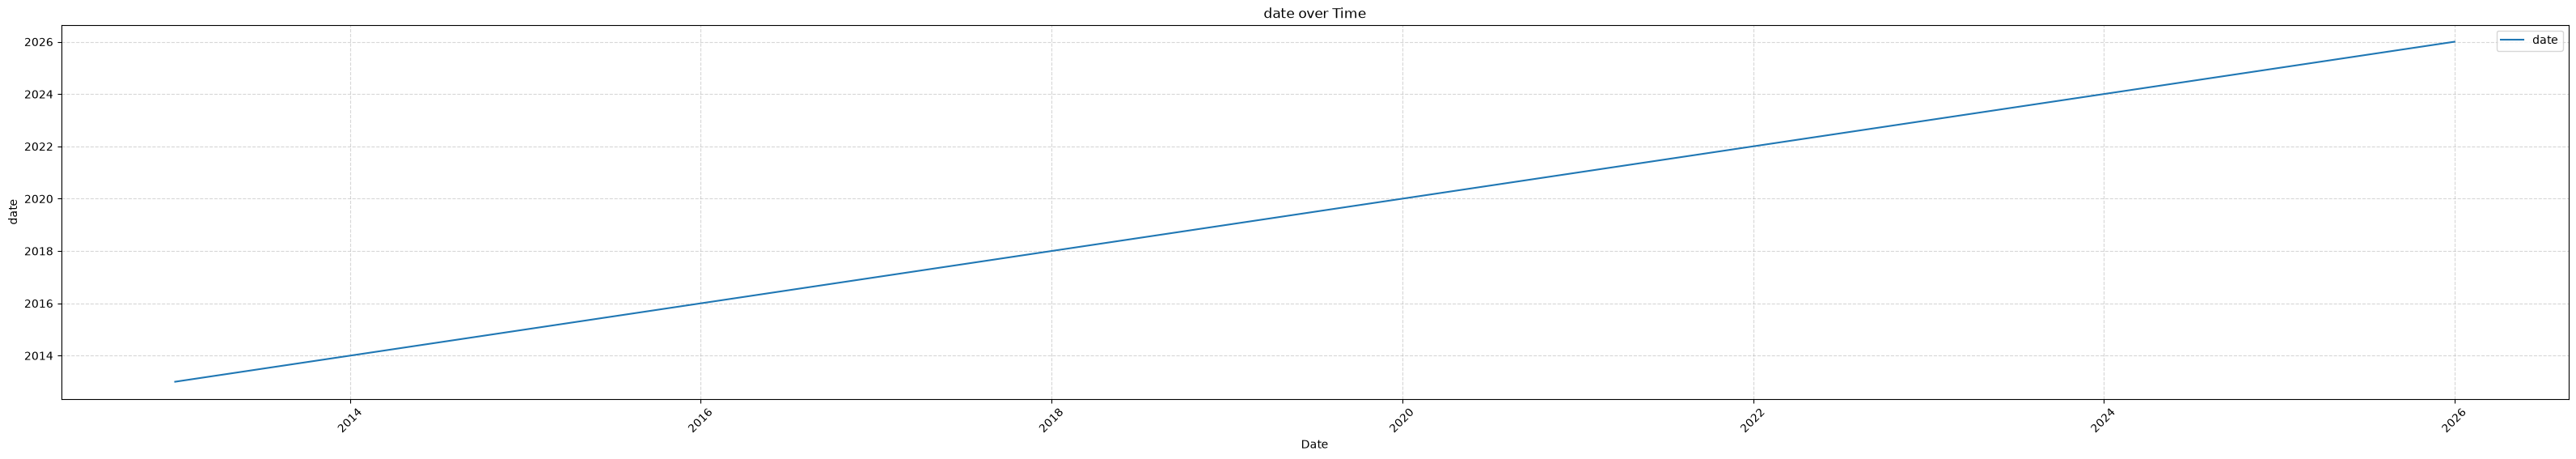

In [11]:
import matplotlib.dates as mdates

for col in numeric:
    plt.figure(figsize=(40, 6))
    
    # Create lineplot
    sns.lineplot(data=df_merged, x='date', y=col, label = col)
 
    plt.xticks(rotation=45)
    
    # Add title and labels
    plt.title(f'{col} over Time')
    plt.xlabel('Date')
 
    plt.grid(True, linestyle='--', alpha=0.5)
 
    plt.show()

## 1.1.1 Features creation

In [12]:
df_merged['covid_period'] = ((df_merged['date']>= pd.Timestamp('2020-03-01')) &
                              (df_merged['date']<= pd.Timestamp('2021-05-31'))).astype(int)

df_merged['ukraine_war'] = (df_merged['date']> pd.Timestamp('2022-02-01')).astype(int)

## 1.2 ADF test: looking for stationarity

In [13]:
numeric_cols  =[ 'workforce', 'inactives', 'employment_rate',
                    'youth_employment_rate', 'activity_rate', 'unemployment_rate',
                    'industry_production_prices', 'companies_trust', 'gasoline_car_price',
                    'diesel_price', 'GPL_price', 'diesel_heatining_price']

In [14]:
stationary_cols = []
non_stationary_cols = []

for col in numeric_cols:
    print('---------------------------------------------')
    print(col)
    print('---------------------------------------------')

    test_staticist = adfuller(df_merged[col])[0]
    adf_criticatical_value_5perc = adfuller(df_merged[col])[4]['5%']
    if test_staticist > adf_criticatical_value_5perc:
        non_stationary_cols.append(col)
        print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
        df_merged[f'{col}_diff'] = df_merged[col] - df_merged[col].shift( 1) # qui facciamo subito la differnziazione

    else:
        stationary_cols.append(col)
        print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')

---------------------------------------------
workforce
---------------------------------------------
-2.57 > -2.88 ==> The time series is NON stationary
---------------------------------------------
inactives
---------------------------------------------
-1.89 > -2.88 ==> The time series is NON stationary
---------------------------------------------
employment_rate
---------------------------------------------
-1.49 > -2.88 ==> The time series is NON stationary
---------------------------------------------
youth_employment_rate
---------------------------------------------
-1.14 > -2.88 ==> The time series is NON stationary
---------------------------------------------
activity_rate
---------------------------------------------
-2.22 > -2.88 ==> The time series is NON stationary
---------------------------------------------
unemployment_rate
---------------------------------------------
0.63 > -2.88 ==> The time series is NON stationary
---------------------------------------------
i

In [15]:
df_merged[[ 'date'] + stationary_cols + non_stationary_cols].to_csv("dataset_FINAL_not_differentiated.csv", index = False)

# Differeziazione

In [16]:
non_stationary_cols = [
 'workforce',
 'inactives',
 'employment_rate',
 'youth_employment_rate',
 'activity_rate',
 'unemployment_rate',
 'industry_production_prices',
 'gasoline_car_price',
 'diesel_price',
 'diesel_heatining_price']

diff_cols=['workforce_diff',  
           'inactives_diff', 
           'employment_rate_diff', 
           'youth_employment_rate_diff',
          'activity_rate_diff', 
          'unemployment_rate_diff', 
          'industry_production_prices_diff', 
          'gasoline_car_price_diff', 
          'diesel_price_diff',
          'diesel_heatining_price_diff']

In [17]:
# df_merged[diff_cols] = df_merged[non_stationary_cols].diff()

In [18]:
df_merged_detrended =  df_merged[['date',   
                                    'workforce_diff', 
                                    'inactives_diff', 
                                    # 'employment_rate', 
                                    'employment_rate_diff', 
                                    'activity_rate_diff', 
                                    'industry_production_prices_diff',
                                    'companies_trust',  
                                    'gasoline_car_price_diff', 
                                    'diesel_price_diff',  
                                    'GPL_price',  
                                    'diesel_heatining_price_diff', 
                                    'unemployment_rate', 
                                    'unemployment_rate_diff', 
                                    # 'covid_period', 
                                    # 'ukraine_war'
                                    ]]

## 1.3 ACF and PACF plot

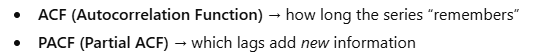

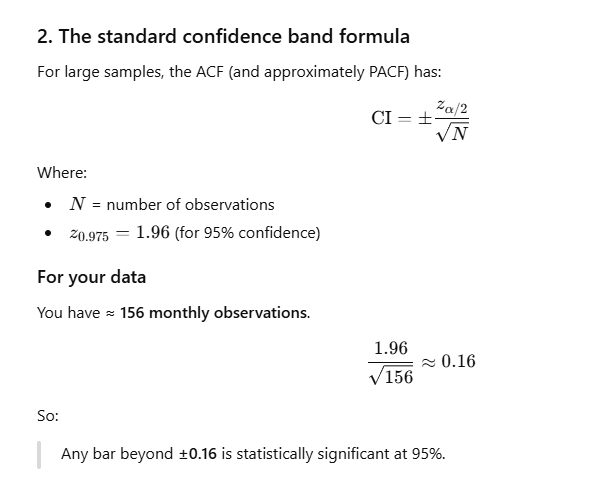

KeyError: 'employment_rate'

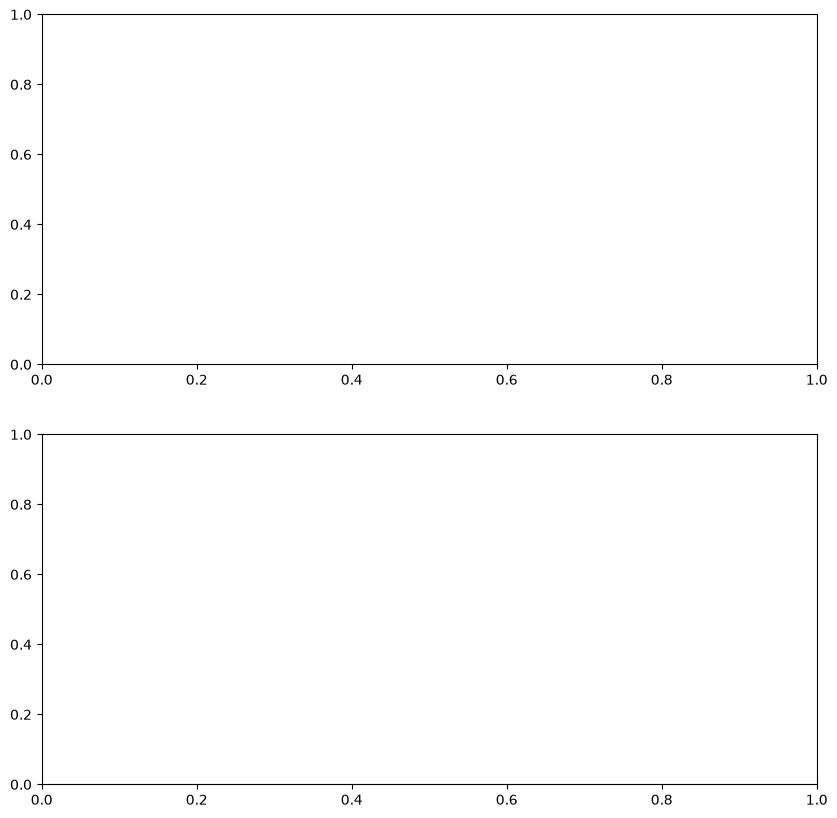

In [19]:
width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df_merged_detrended['employment_rate'],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df_merged_detrended['employment_rate'],lags=36, ax=ax[1], alpha=0.05, method="ywm")

# ax[1].annotate('Strong correlation at lag = 1', xy=(1, 0.6),  xycoords='data',
#             xytext=(0.17, 0.75), textcoords='axes fraction',
#             arrowprops=dict(color='red', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

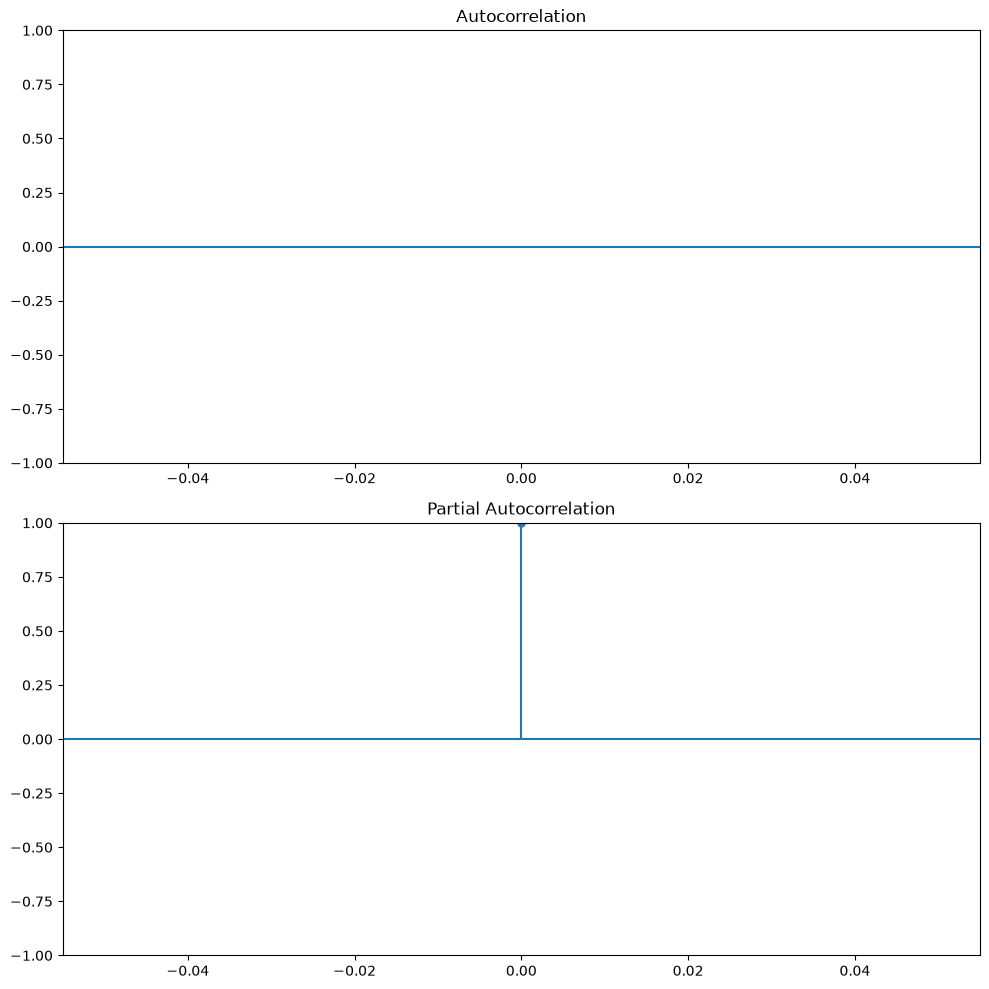

In [ ]:
width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df_merged_detrended['employment_rate_diff'],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df_merged_detrended['employment_rate_diff'],lags=36, ax=ax[1], alpha=0.05, method="ywm")

# ax[1].annotate('Strong correlation at lag = 1', xy=(1, 0.6),  xycoords='data',
#             xytext=(0.17, 0.75), textcoords='axes fraction',
#             arrowprops=dict(color='red', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

## 1.4 Rolling and Lagged features

In [20]:
df_merged_detrended['rolling_mean_3m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=3).mean()
df_merged_detrended['rolling_mean_6m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=6).mean()
df_merged_detrended['rolling_mean_12m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=12).mean()
df_merged_detrended['rolling_std_12m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=12).std()

df_merged_detrended['lag_1m'] = df_merged_detrended['unemployment_rate_diff'].shift(1)
df_merged_detrended['lag_2m'] = df_merged_detrended['unemployment_rate_diff'].shift(2)
df_merged_detrended['lag_3m'] = df_merged_detrended['unemployment_rate_diff'].shift(3)
df_merged_detrended['lag_12m'] = df_merged_detrended['unemployment_rate_diff'].shift(12)


# Uncertainty coefficient

In [21]:
def _validate_and_crosstab(x, y):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return None
    pxy_table = pd.crosstab(df["x"], df["y"], normalize='all')
    if pxy_table.size == 0 or pxy_table.values.sum() == 0:
        return None
    return pxy_table.to_numpy(dtype=float)
 
def uncertainty_coefficients(x,y,base = 2):
    """Compute Theil's U between two categorical variables.
   
    Params
    ------
    x, y: array-like (categorical, string, or discrete)
          Variables of equal length. NaN pairs are dropped pairwise.
    base: float, optional (default = 2)
          Logarithm base for the entropy.
         
    Returns
    -------
    dict with keys:
        - 'U_X_given_Y' : U(X | Y) = I(X;Y) / H(X)
        - 'U_Y_given_X' : U(Y | X) = I(X;Y) / H(Y)
        - 'U_symmetric' : 2 * I(X;Y) / (H(X) + H(Y))   (0 if both entropies are 0)
 
    Notes
    -----
    I(X;Y) = H(X) + H(Y) - H(X,Y)
    H(X|Y) = H(X,Y) - H(Y)
    When H(X)=0 (or H(Y)=0), the corresponding asymmetric U is defined as 0.0.
    """
    pxy = _validate_and_crosstab(x, y)
    if pxy is None:
        return {"U_X_given_Y": np.nan, "U_Y_given_X": np.nan, "U_symmetric": np.nan}
   
    px = pxy.sum(axis = 1)
    py = pxy.sum(axis = 0)
   
    Hx = entropy(px, base=base)
    Hy = entropy(py, base=base)
    Hxy = entropy(pxy.ravel(), base=base)
   
    Ixy = Hx + Hy - Hxy
   
    U_x_given_y = 0.0 if np.isclose(Hx,0.0) else Ixy / Hx
    U_y_given_x = 0.0 if np.isclose(Hy,0.0) else Ixy / Hy
   
    den = Hx + Hy
    U_sym = 0.0 if np.isclose(den, 0.0) else (2.0 * Ixy) / den
   
    return {"U_X_given_Y": U_x_given_y, "U_Y_given_X": U_y_given_x, "U_symmetric": U_sym}
 
def pairwise_uncertainty(df, cols = None, base=2, symmetric=False):
    """Compute a pairwise matrix of Theil's uncertainty coefficients for a DataFrame.
   
    Params
    ------
        df: pandas.DataFrame
            The data. Non-categorical columns are allowed.
        cols: list-like or None
              Subset of cols to include. Defaults to all columns.
        base: float
              Entropy base (2 for bits)
        symmetric: bool
                   If True, returns the symmetric coefficient, else returns
                   U(X|Y) with rows = X, cols = Y.
   
    Returns
    -------
    pandas.DataFrame
        Matrix of uncertainty coeffs.
    """
    if cols is None:
        cols = list(df.columns)
   
    cols = list(cols)
    res = pd.DataFrame(index=cols, columns=cols, dtype=float)
   
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                res.iloc[i,j] = 1
                continue
            coeffs = uncertainty_coefficients(df[c1], df[c2], base=base)
            res.iloc[i,j] = coeffs["U_symmetric"] if symmetric else coeffs["U_X_given_Y"]
   
    return res
 

In [22]:
cols_coeff = ['date',  'workforce_diff', 'inactives_diff',
       'employment_rate_diff', 'youth_employment_rate_diff',
       'activity_rate_diff', 'unemployment_rate_diff',
       'industry_production_prices_diff', 'companies_trust',
       'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
       'diesel_heatining_price_diff', 'covid_period', 'ukraine_war']

In [23]:
df_to_corr = df_merged_detrended[df_merged_detrended['date']<= '2025/07/01']
df_to_corr = df_to_corr[cols_coeff]

df_unc_corr = pairwise_uncertainty(df_to_corr)


KeyError: "['youth_employment_rate_diff', 'covid_period', 'ukraine_war'] not in index"

In [25]:

# plt.figure(figsize=(15,10))
# sns.heatmap(df_unc_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# plt.title("Correlation Heatmap")
# plt.show()

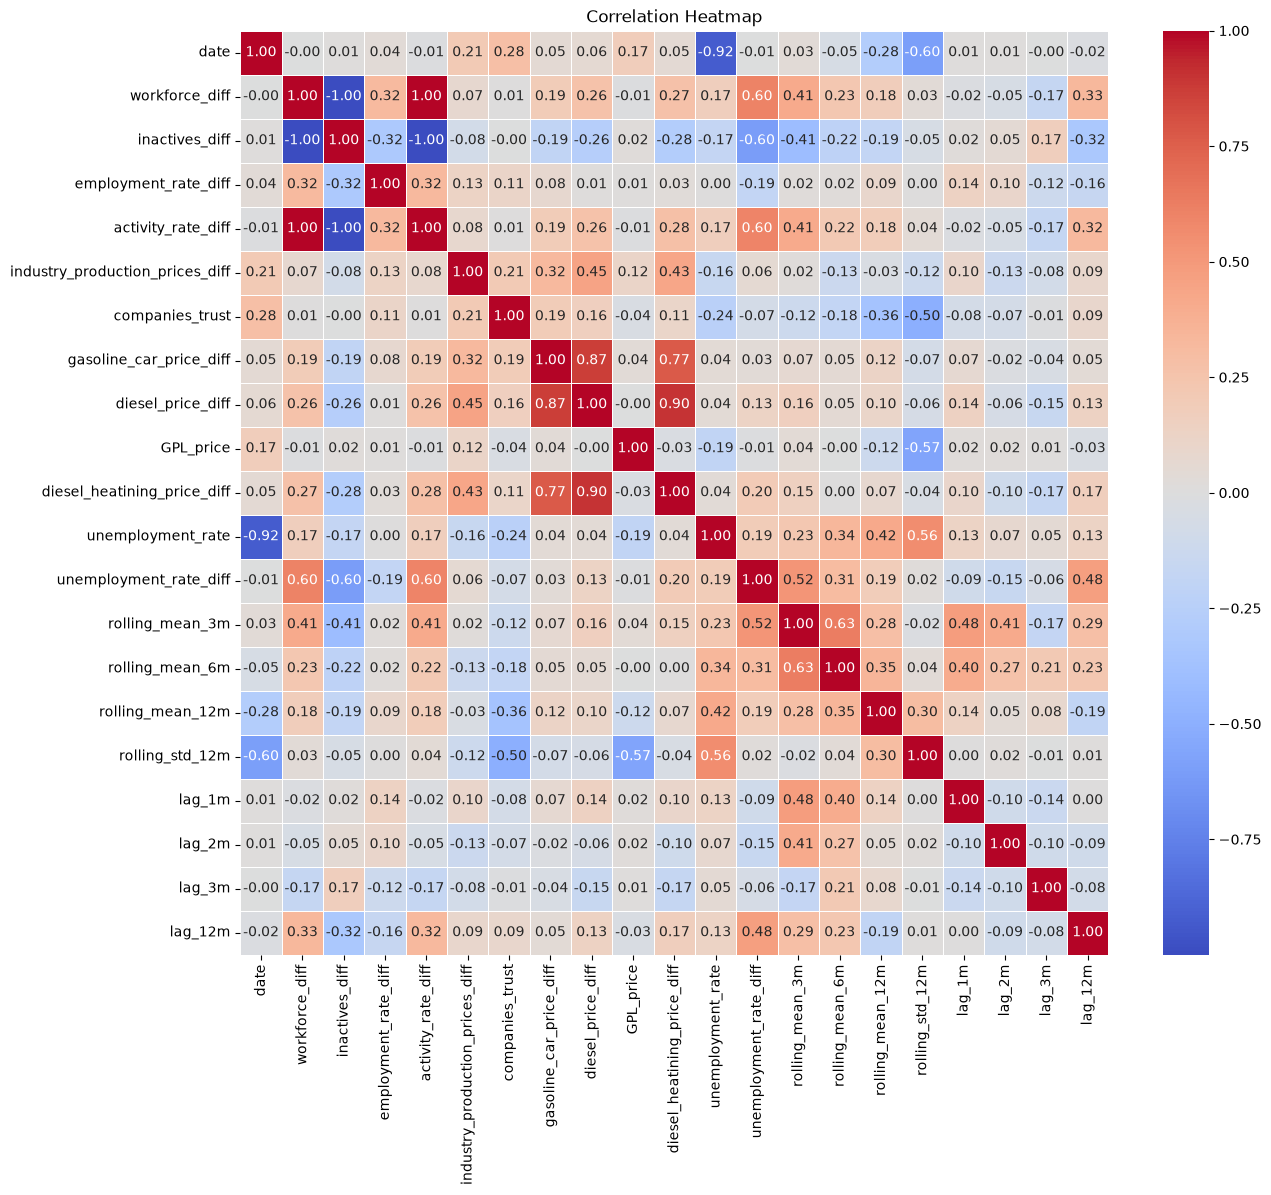

In [26]:
matrix = df_to_corr.corr(method = 'spearman')

plt.figure(figsize=(14,12))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# PCA

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [28]:
df_merged_detrended = df_merged_detrended.iloc[13:] # questo serve a togliere le prime 13 righe che hanno dei valori NUll

In [30]:
X_labour_market = df_merged_detrended[[  'workforce_diff', 'inactives_diff',
                                            'employment_rate_diff', #'youth_employment_rate_diff',
                                            'activity_rate_diff', 'unemployment_rate_diff']]

X_price_energy = df_merged_detrended[[ 'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price', 'diesel_heatining_price_diff']]

X_macroeconomic_variables = df_merged_detrended[[  'industry_production_prices_diff', 'companies_trust' ]]

scaler = StandardScaler()
X_labour_market_scaled = scaler.fit_transform(X_labour_market)
X_price_energy_scaled = scaler.fit_transform(X_price_energy)
X_macroeconomic_variables_scaled = scaler.fit_transform(X_macroeconomic_variables)

In [31]:
pca = PCA(n_components=2)
df_merged_detrended[['PCA_labour_market_1', 'PCA_labour_market_2']] = pca.fit_transform(X_labour_market_scaled)
df_merged_detrended[['PCA_price_energy_1', 'PCA_price_energy_2']] = pca.fit_transform(X_price_energy)
df_merged_detrended[['PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2']] = pca.fit_transform(X_macroeconomic_variables)

In [34]:
pca_all = PCA()

all_columns = [#'GDPGrowth', 'WorkingDays', 'fixed_term_diff',   'permanent_diff', 
               'workforce_diff', 'inactives_diff',
                'employment_rate_diff', #'youth_employment_rate_diff',
                'activity_rate_diff', 'unemployment_rate_diff',
                'industry_production_prices_diff', 'companies_trust',
                'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
                'diesel_heatining_price_diff', 
                #'covid_period', 'ukraine_war',
                ]

df_merged_detrended[all_columns]

all_columns_scaled = scaler.fit_transform(df_merged_detrended[all_columns])

# df_merged_detrended[['PCA_labour_market_1', 'PCA_labour_market_2']] = 
df_temp = pca_all.fit_transform(all_columns_scaled)



In [35]:
pca_all.explained_variance_ratio_

array([3.72655938e-01, 2.06607596e-01, 1.20761231e-01, 9.61303651e-02,
       8.50283089e-02, 6.81488772e-02, 2.45535857e-02, 2.10264585e-02,
       4.94921394e-03, 1.25486684e-04, 1.29392597e-05])

In [36]:
# exp_var_cumul = np.cumsum(pca_all.explained_variance_ratio_)
# plt.bar(range(1, len(pca_all.explained_variance_)+1), pca_all.explained_variance_)
# plt.plot(range(1, len(pca_all.explained_variance_)+1), exp_var_cumul, c='red', label='Cumulative Explained Variance')
# plt.legend(loc='upper left')
# plt.xlabel('Number of components')
# plt.ylabel('Explained variance (eigenvalues)')
# plt.title('Scree plot')
# plt.show()

# #il grafico mostra che il numero idela di componeneti da tenere è tra 7 e 8, perché dopo la curva rossa tende ad appiattirsi
 

In [39]:
df_merged_detrended = df_merged_detrended[['date', 'workforce_diff', 'inactives_diff',
                                            'employment_rate_diff', #'youth_employment_rate_diff',
                                            'activity_rate_diff', 'unemployment_rate_diff',
                                            'industry_production_prices_diff', 'companies_trust',
                                            'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
                                            'diesel_heatining_price_diff', #'covid_period', 'ukraine_war', 
                                            'rolling_mean_3m', 'rolling_mean_6m', 'rolling_mean_12m', 'rolling_std_12m', 
                                            'lag_1m', 'lag_2m', 'lag_3m', 'lag_12m', 
                                            'PCA_labour_market_1', 'PCA_labour_market_2',
                                            'PCA_price_energy_1', 'PCA_price_energy_2',
                                            'PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2']]

In [40]:
set(df_merged_detrended.columns.tolist()) -set(df_merged.columns.tolist())

{'PCA_labour_market_1',
 'PCA_labour_market_2',
 'PCA_macroeconomic_variables_1',
 'PCA_macroeconomic_variables_2',
 'PCA_price_energy_1',
 'PCA_price_energy_2',
 'lag_12m',
 'lag_1m',
 'lag_2m',
 'lag_3m',
 'rolling_mean_12m',
 'rolling_mean_3m',
 'rolling_mean_6m',
 'rolling_std_12m'}

In [41]:
df_merged.to_csv("dataset_FINAL.csv")

In [42]:
df_mising_cols = df_merged_detrended[['date','PCA_labour_market_1', 'PCA_labour_market_2',  'PCA_macroeconomic_variables_1', 
                                      'PCA_macroeconomic_variables_2', 'PCA_price_energy_1', 'PCA_price_energy_2', 
                                      'lag_12m', 'lag_1m', 'lag_2m', 'lag_3m', 'rolling_mean_12m', 
                                      'rolling_mean_3m',  'rolling_mean_6m', 'rolling_std_12m']]

In [43]:
df_final = df_merged.merge(df_mising_cols, how ='inner', on = 'date')
df_final.to_csv("dataset_FINAL_all_variables.csv", index=False)

# BACK UP

## 1.2 Correlation

In [44]:
df_to_corr = df_merged[df_merged['date']<= '2025/07/01']
df_to_corr.drop(columns = 'date', inplace= True)

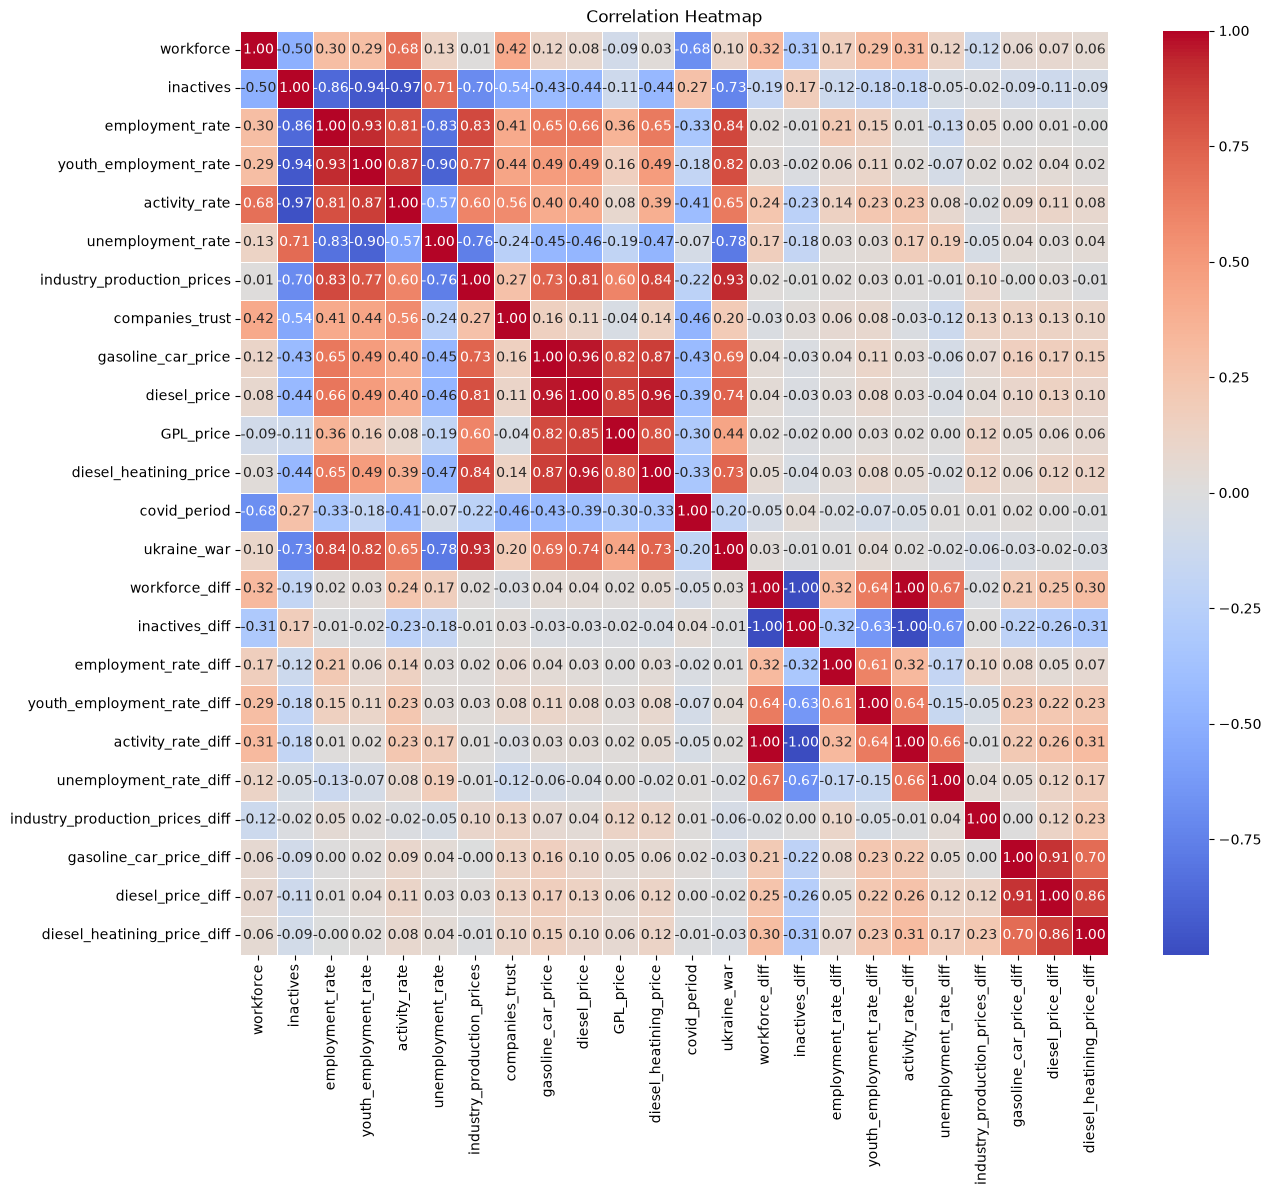

In [45]:
matrix = df_to_corr.corr()

plt.figure(figsize=(14,12))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [46]:
matrix[matrix.TotSales >= 0.4]['TotSales']

AttributeError: 'DataFrame' object has no attribute 'TotSales'

In [47]:
def _validate_and_crosstab(x, y):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return None
    pxy_table = pd.crosstab(df["x"], df["y"], normalize='all')
    if pxy_table.size == 0 or pxy_table.values.sum() == 0:
        return None
    return pxy_table.to_numpy(dtype=float)
 
def uncertainty_coefficients(x,y,base = 2):
    """Compute Theil's U between two categorical variables.
   
    Params
    ------
    x, y: array-like (categorical, string, or discrete)
          Variables of equal length. NaN pairs are dropped pairwise.
    base: float, optional (default = 2)
          Logarithm base for the entropy.
         
    Returns
    -------
    dict with keys:
        - 'U_X_given_Y' : U(X | Y) = I(X;Y) / H(X)
        - 'U_Y_given_X' : U(Y | X) = I(X;Y) / H(Y)
        - 'U_symmetric' : 2 * I(X;Y) / (H(X) + H(Y))   (0 if both entropies are 0)
 
    Notes
    -----
    I(X;Y) = H(X) + H(Y) - H(X,Y)
    H(X|Y) = H(X,Y) - H(Y)
    When H(X)=0 (or H(Y)=0), the corresponding asymmetric U is defined as 0.0.
    """
    pxy = _validate_and_crosstab(x, y)
    if pxy is None:
        return {"U_X_given_Y": np.nan, "U_Y_given_X": np.nan, "U_symmetric": np.nan}
   
    px = pxy.sum(axis = 1)
    py = pxy.sum(axis = 0)
   
    Hx = entropy(px, base=base)
    Hy = entropy(py, base=base)
    Hxy = entropy(pxy.ravel(), base=base)
   
    Ixy = Hx + Hy - Hxy
   
    U_x_given_y = 0.0 if np.isclose(Hx,0.0) else Ixy / Hx
    U_y_given_x = 0.0 if np.isclose(Hy,0.0) else Ixy / Hy
   
    den = Hx + Hy
    U_sym = 0.0 if np.isclose(den, 0.0) else (2.0 * Ixy) / den
   
    return {"U_X_given_Y": U_x_given_y, "U_Y_given_X": U_y_given_x, "U_symmetric": U_sym}
 
def pairwise_uncertainty(df, cols = None, base=2, symmetric=False):
    """Compute a pairwise matrix of Theil's uncertainty coefficients for a DataFrame.
   
    Params
    ------
        df: pandas.DataFrame
            The data. Non-categorical columns are allowed.
        cols: list-like or None
              Subset of cols to include. Defaults to all columns.
        base: float
              Entropy base (2 for bits)
        symmetric: bool
                   If True, returns the symmetric coefficient, else returns
                   U(X|Y) with rows = X, cols = Y.
   
    Returns
    -------
    pandas.DataFrame
        Matrix of uncertainty coeffs.
    """
    if cols is None:
        cols = list(df.columns)
   
    cols = list(cols)
    res = pd.DataFrame(index=cols, columns=cols, dtype=float)
   
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                res.iloc[i,j] = 1
                continue
            coeffs = uncertainty_coefficients(df[c1], df[c2], base=base)
            res.iloc[i,j] = coeffs["U_symmetric"] if symmetric else coeffs["U_X_given_Y"]
   
    return res
 

In [48]:
df_unc_corr = pairwise_uncertainty(df_to_corr)
df_unc_corr

,workforce,inactives,employment_rate,youth_employment_rate,activity_rate,unemployment_rate,industry_production_prices,companies_trust,gasoline_car_price,diesel_price,...,workforce_diff,inactives_diff,employment_rate_diff,youth_employment_rate_diff,activity_rate_diff,unemployment_rate_diff,industry_production_prices_diff,gasoline_car_price_diff,diesel_price_diff,diesel_heatining_price_diff
workforce,1.0,1.0,0.972553,0.986501,0.965682,0.971862,0.903940,0.903432,1.0,1.0,...,1.0,1.0,0.975326,0.937496,0.961022,0.961022,0.754218,1.0,0.998156,1.0
inactives,1.0,1.0,0.972553,0.986501,0.965682,0.971862,0.903940,0.903432,1.0,1.0,...,1.0,1.0,0.975326,0.937496,0.961022,0.961022,0.754218,1.0,0.998156,1.0
employment_rate,1.0,1.0,1.000000,0.986120,0.964713,0.971068,0.903110,0.900707,1.0,1.0,...,1.0,1.0,0.974624,0.935718,0.959913,0.959913,0.747225,1.0,0.998103,1.0
youth_employment_rate,1.0,1.0,0.972177,1.000000,0.965212,0.971477,0.902625,0.902110,1.0,1.0,...,1.0,1.0,0.974985,0.936634,0.960484,0.960484,0.750827,1.0,0.998130,1.0
activity_rate,1.0,1.0,0.971577,0.986021,1.000000,0.970862,0.900526,0.900000,1.0,1.0,...,1.0,1.0,0.974490,0.935380,0.959702,0.959702,0.747804,1.0,0.998093,1.0
unemployment_rate,1.0,1.0,0.971758,0.986110,0.964688,1.000000,0.901159,0.900636,1.0,1.0,...,1.0,1.0,0.974605,0.935672,0.959884,0.959884,0.747043,1.0,0.998102,1.0
industry_production_prices,1.0,1.0,0.971660,0.985066,0.962035,0.968872,1.000000,0.893170,1.0,1.0,...,1.0,1.0,0.972680,0.930795,0.956843,0.956843,0.742934,1.0,0.997958,1.0
companies_trust,1.0,1.0,0.969619,0.985058,0.962014,0.968854,0.893672,1.000000,1.0,1.0,...,1.0,1.0,0.972665,0.934843,0.958862,0.956819,0.729757,1.0,0.997957,1.0
gasoline_car_price,1.0,1.0,0.972553,0.986501,0.965682,0.971862,0.903940,0.903432,1.0,1.0,...,1.0,1.0,0.975326,0.937496,0.961022,0.961022,0.754218,1.0,0.998156,1.0
diesel_price,1.0,1.0,0.972553,0.986501,0.965682,0.971862,0.903940,0.903432,1.0,1.0,...,1.0,1.0,0.975326,0.937496,0.961022,0.961022,0.754218,1.0,0.998156,1.0


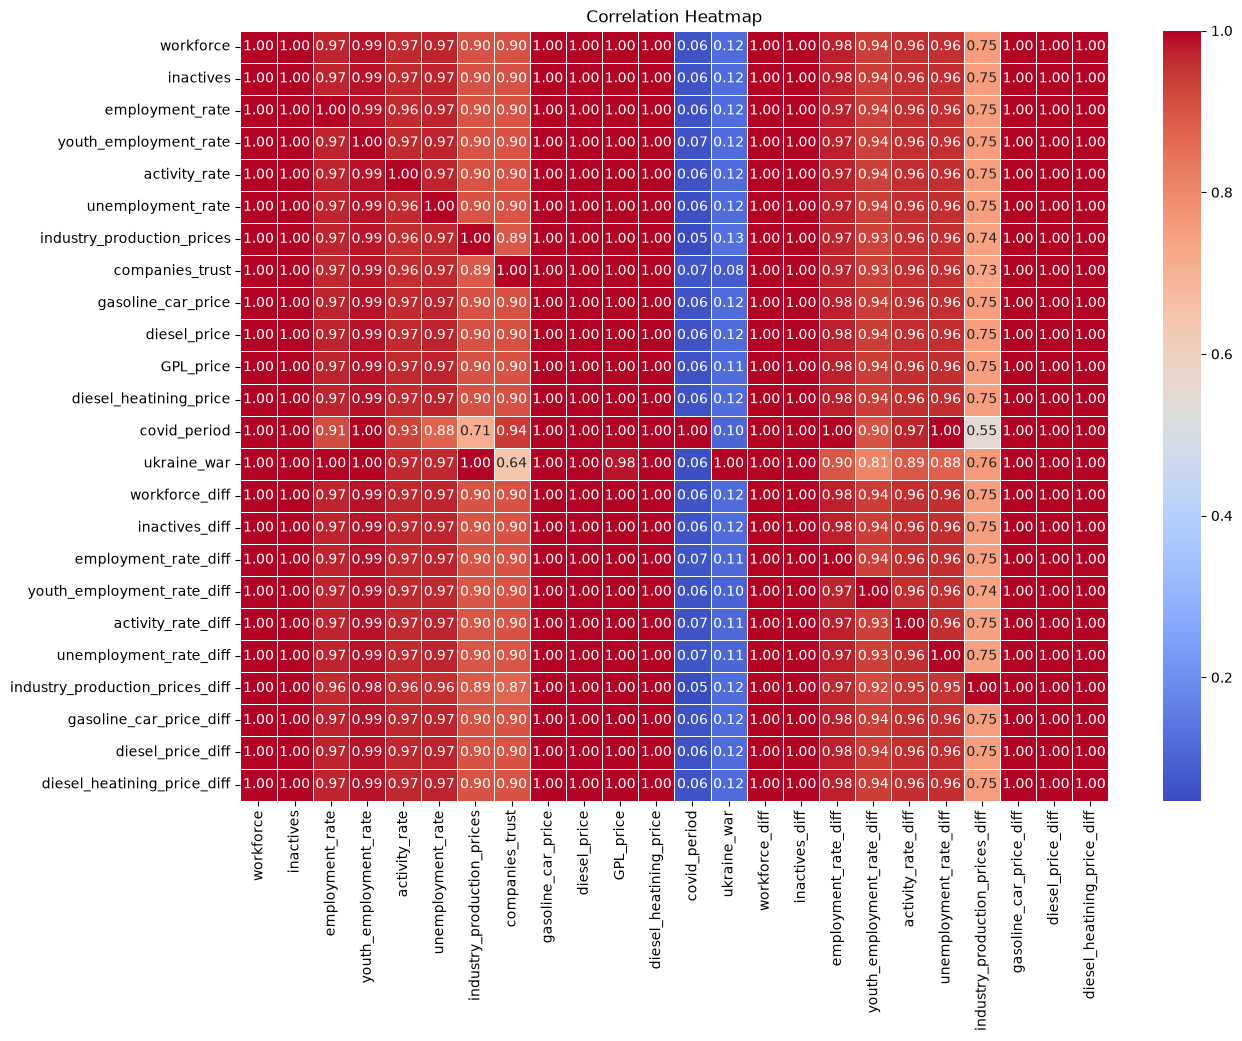

In [49]:

plt.figure(figsize=(14,10))
sns.heatmap(df_unc_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()